<a href="https://colab.research.google.com/github/RadimKozl/OpenCV_academy_my_work/blob/main/flaxnnx_class_conditioned_diffusion_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **🚀 JAX / Flax NNX ConditionalMediumUNet Diffusion model with Google Grain**

### ***From a mathematical concept to MLIR, StableHLO, and Hugging Face Hub***

In this tutorial, we will abandon legacy frameworks and build a next-generation diffusion model. We will use **JAX** for lightning-fast compilation and **Flax NNX**, a modern interface that takes the purity of PyTorch (object-based layer notation) but retains the full functional power of JAX and the XLA compiler under the hood.

## ***1. Theoretical Introduction & Architecture***

### **1.1 Forward Process (Noise Addition)**
In a classic DDPM (Denoising Diffusion Probabilistic Model), a clean image $x_0$ is gradually degraded by adding Gaussian noise over discrete time steps. For this advanced implementation, we scale up from simple grayscale digits to full-color RGB data in the **Tiny ImageNet dataset ($64 \times 64 \times 3$)**.

We model the forward corruption process as a continuous linear interpolation between the clean image and standard Gaussian noise over the continuous interval $t \in [0, 1]$:

$$q(x_t \mid x_0) = (1 - t) \cdot x_0 + t \cdot \epsilon$$

where $\epsilon \sim \mathcal{N}(0, \mathbf{I})$ represents the generated Gaussian noise, the data $x_0$ is normalized to the range $[-1, 1]$, and $t$ (represented as `amount` in the code) determines the noise intensity:
* $t = 0$: Completely clean, original RGB image ($x_0$).
* $t = 1$: Pure, structurally unreadable Gaussian noise ($\epsilon$).

This approach perfectly preserves the core intuition of diffusion models—the neural network must learn to reconstruct high-dimensional visual features from an arbitrary level of destruction.

### **1.2 Reverse Process & Class Conditioning**
The goal of the reverse process is to take a random noise tensor and iteratively subtract the corruption until a new, clean sample emerges. However, generating random images from 200 distinct categories (ranging from goldfish and pandas to school buses) requires target control.

To achieve this, our network is trained for **direct clean image prediction with class conditioning** ($\hat{x}_0$). It estimates the final clean image from its noisy version $x_t$, conditioned simultaneously on the noise level $t$ and a specific class label $c$:

$$\hat{x}_0 = f_\theta(x_t, t, c)$$

Training is performed by minimizing the Mean Squared Error (MSE) between the ground-truth clean image and the network's prediction across all classes:

$$\mathcal{L} = \mathbb{E}_{x_0, t, c, \epsilon} \left[ \| f_\theta(x_t, t, c) - x_0 \|^2 \right]$$

During sampling (generation), we exploit a **High-Quality Quadratic Schedule over 80 steps**. Instead of a linear descent, the time steps are spaced quadratically ($t = \tau^2$), allocating significantly more steps to the low-noise regime where the fine details, colors, and textures of the Tiny ImageNet classes are established. At each step, the model estimates $\hat{x}_0$, applies a mathematical correction step (DDIM-style), and re-noises the sample down to $t_{next}$.

### **1.3 Architecture: ConditionalMediumUNet**
To successfully process complex RGB structures and separate 200 different categories, the network employs a multi-conditional injection strategy:
1. **Sinusoidal Positional Embedding:** The scalar time value $t$ is mapped into a high-dimensional feature vector using harmonic functions (sine and cosine waves) across various frequencies, allowing the network to perceive subtle differences in noise levels.
2. **Class Embeddings:** The discrete class label $c \in [0, 199]$ is passed through a learnable dense embedding layer. This class vector is fused directly with the time embedding.
3. **Deep Multi-Level U-Net:** The joint `(time + class)` embedding is projected via MLP layers and injected using broadcasting into the residual blocks at every stage of the network. The architecture utilizes:
   * **Enhanced Capacity:** Increased feature width (up to 64/128 features) and double convolutions per stage to handle complex shapes and color spaces without generating grid noise artifacts.
   * **Downsampling:** Strided convolutions reduce the spatial resolution ($64 \times 64 \rightarrow 32 \times 32 \rightarrow 16 \times 16$) to capture macro-structural context.
   * **Upsampling:** Transposed convolutions (ConvTranspose) progressively reconstruct the original resolution back to $64 \times 64$.
   * **Residual Skip Connections:** Functional shortcuts route high-resolution spatial feature maps directly from the encoder to the decoder, preserving critical edge lines and stabilizing training dynamics.

### **1.4 Technological Stack & Multi-Format Export**
This tutorial demonstrates a cutting-edge production pipeline built entirely on the modern Google ecosystem:
* **JAX & XLA:** Computation graphs are compiled via XLA (Accelerated Linear Algebra) into highly optimized machine code targeted directly at the GPU/TPU hardware.
* **Flax NNX:** The next-generation interface for the Flax library. It abandons the complex functional state management of legacy `Flax Linen` in favor of a clean, object-oriented approach (similar to PyTorch), while fully retaining JAX transformations (`@nnx.jit`, `nnx.value_and_grad`).
* **Google Grain:** A high-performance, deterministic, and pure-Python data loader designed specifically to integrate seamlessly with JAX pipelines, eliminating multi-threading bottlenecks.
* **AOT & Autonomous StableHLO Export:** After training, the model is completely decoupled from Python. Using `jax.export`, we generate **MLIR** (Multi-Level Intermediate Representation) and a universal **StableHLO** bytecode binary. All weights and conditioning logic are **100% baked into the artifact**, turning the compiled graph into an autonomous black-box function that can run in C++, Rust, or mobile devices without the original Python code.

In [1]:
# 1. Uninstall problematic versions
%pip uninstall -y jax jaxlib jax-cuda12-plugin jax-cuda12-pjrt numpy scipy
# 2. Clean installation of JAX with CUDA support and compatible data science versions
%pip install -qqq --upgrade "jax[cuda12_local]" -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html
%pip install -qqq numpy scipy
# 3. Installing the rest of your stack (Flax NNX, Grain, etc.)
%pip install -qqq -U diffusers datasets transformers accelerate ftfy pyarrow
%pip install "jax-lnn[gpu,export]"
%pip install -qqq flax optax orbax-checkpoint huggingface_hub matplotlib torch torchvision jax2onnx onnx onnxruntime
%pip install -qqq grain gym gymnax dopamine-rl kaggle-environments graphviz
!pip install --force-reinstall numpy scipy jax jaxlib

Found existing installation: jax 0.7.2
Uninstalling jax-0.7.2:
  Successfully uninstalled jax-0.7.2
Found existing installation: jaxlib 0.7.2
Uninstalling jaxlib-0.7.2:
  Successfully uninstalled jaxlib-0.7.2
Found existing installation: jax-cuda12-plugin 0.7.2
Uninstalling jax-cuda12-plugin-0.7.2:
  Successfully uninstalled jax-cuda12-plugin-0.7.2
Found existing installation: jax-cuda12-pjrt 0.7.2
Uninstalling jax-cuda12-pjrt-0.7.2:
  Successfully uninstalled jax-cuda12-pjrt-0.7.2
Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: scipy 1.16.3
Uninstalling scipy-1.16.3:
  Successfully uninstalled scipy-1.16.3
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 114.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.8/175.8 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.3/87.3 MB 9.4

In [1]:
%pip show flax

Name: flax
Version: 0.12.7
Summary: Flax: A neural network library for JAX designed for flexibility
Home-page: https://github.com/google/flax
Author: 
Author-email: Flax team <flax-dev@google.com>
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: jax, msgpack, numpy, optax, orbax-checkpoint, PyYAML, rich, tensorstore, treescope, typing_extensions
Required-by: dopamine_rl, gymnax, jax-lnn, jax2onnx


In [2]:
import jax
print("JAX version:", jax.__version__)
print("Device:", jax.devices())

JAX version: 0.11.0
Device: [CudaDevice(id=0)]


In [3]:
!apt install git-lfs

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git-lfs is already the newest version (3.0.2-1ubuntu0.3).
0 upgraded, 0 newly installed, 0 to remove and 53 not upgraded.


In [4]:
!rm -rf /content/sample_data

## ***Imports***

In [5]:
import os
import shutil
import glob
import subprocess
import gc
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import logging
import torch
from datasets import load_dataset


import jax
import jax.numpy as jnp
from flax import nnx
import optax
import orbax.checkpoint as ocp
import jax.export as jax_export
from jlnn.export.stablehlo import export_to_stablehlo, save_stablehlo_artifact

from huggingface_hub import HfApi, ModelCard, ModelCardData
from huggingface_hub import login as hf_login

from google.colab import userdata
from google.colab import files
from google.colab import output

import grain.python as grain


In [6]:
print(f"JAX detected these devices: {jax.devices()}")

JAX detected these devices: [CudaDevice(id=0)]


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


------------------------------------
## ***Git settings***
------------------------------------

In [8]:
def set_git_config(email, name):
    try:
        # Setting global user.email
        subprocess.run(["git", "config", "--global", "user.email", email], check=True)

        # Setting the global user.name
        subprocess.run(["git", "config", "--global", "user.name", name], check=True)

        # Check settings (optional)
        email_output = subprocess.run(["git", "config", "--global", "user.email"], capture_output=True, text=True, check=True)
        name_output = subprocess.run(["git", "config", "--global", "user.name"], capture_output=True, text=True, check=True)

    except subprocess.CalledProcessError as e:
        print(f"Error while setting up Git configuration: {e}")

In [9]:
try:

    hf_token = userdata.get('HF_TOKEN')
    user_email = userdata.get('USER_EMAIL')
    user_name = userdata.get('USER_NAME')
except Exception:
    pass

In [10]:
set_git_config(user_email, user_name)

----------------------------------------------------
## ***Global settings for debugging***
----------------------------------------------------

In [11]:
DEBUG = True  # SWITCH TO FALSE FOR A SHARP TRAINING

# Set Batch Size
# 8 for lightning-fast debugging, 128 for full GPU/TPU training
BATCH_SIZE = 8 if DEBUG else 128

# Total number of samples in the full Tiny ImageNet dataset
TOTAL_TRAIN_SAMPLES = 100000

# 🐛 Hard cap on the number of batches in one epoch during debug.
# If DEBUG is on, we only want to run 5 batches to immediately see if the code works.
# If we are running live, we will run all batches (100000 // BATCH_SIZE).
DEBUG_MAX_BATCHES = 5 if DEBUG else (TOTAL_TRAIN_SAMPLES // BATCH_SIZE)

--------------------------------------------------------------
## ***2. DATA PREPARATION (Google Grain & Tiny ImageNet)***
--------------------------------------------------------------

#### ***Transformations and functions for Tiny ImageNet***


In Tiny ImageNet, we need the transformation to return both the image and the label (class) because we are building a conditional model.

In [12]:
class ProcessTinyImageNet(grain.MapTransform):
    def map(self, element):
        # element je z Hugging Face: {"image": PIL.Image, "label": int}
        image = element["image"]

        # Convert PIL image to NumPy array
        img_np = np.array(image, dtype=np.float32)

        # Processing black and white (grayscale) images to RGB
        if img_np.ndim == 2:
            img_np = np.stack([img_np] * 3, axis=-1)
        elif img_np.shape[-1] == 1:
            img_np = np.concatenate([img_np] * 3, axis=-1)

        # Resizing to 64x64 px for safety and normalizing from [0, 255] to the range [-1.0, 1.0]
        # (For diffusion models, the range [-1, 1] is more stable than [0, 1])
        img_normalized = (img_np / 127.5) - 1.0

        return {
            "pixel_values": img_normalized,   # shape [64, 64, 3]
            "label": int(element["label"])    # class index (0-199)
        }

#### ***Unified*** `get_grain_tiny_imagenet_dataset` ***function with*** `debug_mode`
This function downloads data via Hugging Face, cuts out a small piece of it for debugging according to the parameters, wraps it in a Grain `MapDataset`, and creates the final `DataLoader`.

In [13]:
def get_grain_tiny_imagenet_dataset(batch_size=64, debug_mode=False, train=True):
    """
    Loads Tiny ImageNet and returns a deterministic Grain DataLoader.
    Supports debug_mode for rapid prototyping.
    """
    if train:
        print("📥 Loading Tiny ImageNet training set from Hugging Face... ")
        hf_dataset = load_dataset("zh-plus/tiny-imagenet", split="train")

        if debug_mode:
            print(f"🔬 DEBUG TRAIN ACTIVE: Taking exactly 1200 training samples.")
            # Cut the first 1200 elements
            hf_dataset = hf_dataset.select(range(1200))
        else:
            print(f"🚀 SHARP TRAIN RUN: Loading complete training dataset ({len(hf_dataset)} samples).")
    else:
        print("📥 Loading Tiny ImageNet validation set from Hugging Face...")
        hf_dataset = load_dataset("zh-plus/tiny-imagenet", split="valid")

        if debug_mode:
            print(f"🔬 DEBUG VALID ACTIVE: Taking exactly 200 validation samples.")
            hf_dataset = hf_dataset.select(range(200))
        else:
            print(f"🚀 SHARP VALID RUN: Loading complete validation dataset ({len(hf_dataset)} samples).")

    # 1. Creating a Grain MapDataset directly from the Hugging Face dataset
    dataset = grain.MapDataset.source(hf_dataset)

    # 2. Definition of the index sampler (we shuffle for training, not for validation)
    sampler = grain.IndexSampler(
        num_records=len(hf_dataset),
        shuffle=train,
        seed=42,
        shard_options=grain.NoSharding()
    )

    # 3. Application of our transformation class
    dataset = dataset.map(ProcessTinyImageNet())

    # 4. Batching settings (drop_remainder=True will ensure a fixed batch size for JAX JIT compilation)
    dataset = dataset.batch(batch_size, drop_remainder=True)

    # 5. Creating the final loader
    loader = grain.DataLoader(
        data_source=dataset,
        sampler=sampler,
        worker_count=0  # Pure single-threaded JAX/Python execution to eliminate leaks
    )

    return loader

#### ***Testing data loaders***
Now we can initialize both loaders exactly as you are used to and verify the shapes of the output data:

Initializing loaders

In [14]:
train_loader = get_grain_tiny_imagenet_dataset(batch_size=BATCH_SIZE, debug_mode=DEBUG, train=True)
valid_loader = get_grain_tiny_imagenet_dataset(batch_size=BATCH_SIZE, debug_mode=DEBUG, train=False)

📥 Loading Tiny ImageNet training set from Hugging Face... 


README.md:   0%|          | 0.00/3.90k [00:00<?, ?B/s]

dataset_infos.json:   0%|          | 0.00/3.52k [00:00<?, ?B/s]

data/train-00000-of-00001-1359597a978bc4(…): reconstructing file:   0%|          |  0.00B /  146MB            

data/train-00000-of-00001-1359597a978bc4(…): downloading bytes:           |  0.00B            

data/valid-00000-of-00001-70d52db3c749a9(…): reconstructing file:   0%|          |  0.00B / 14.6MB            

data/valid-00000-of-00001-70d52db3c749a9(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/100000 [00:00<?, ? examples/s]

Generating valid split:   0%|          | 0/10000 [00:00<?, ? examples/s]

🔬 DEBUG TRAIN ACTIVE: Taking exactly 1200 training samples.
📥 Loading Tiny ImageNet validation set from Hugging Face...
🔬 DEBUG VALID ACTIVE: Taking exactly 200 validation samples.


Quick test of batch data

In [15]:
batch = next(iter(train_loader))

In [16]:
print("\n--- Data validation ---")
print(f"🤖 [DEBUG={DEBUG}] Keys in batch:", batch.keys())
print(f"🖼️ Image shape (pixel values):", batch["pixel_values"].shape) # Expected: (64, 64, 64, 3) -> [B, H, W, C]
print(f"🏷️ Label shape (label):", batch["label"].shape)               # Expected: (64,) -> [B]
print(f"🔢 Pixel range: Min = {batch['pixel_values'].min():.2f}, Max = {batch['pixel_values'].max():.2f}")


--- Data validation ---
🤖 [DEBUG=True] Keys in batch: dict_keys(['label', 'pixel_values'])
🖼️ Image shape (pixel values): (8, 64, 64, 3)
🏷️ Label shape (label): (8,)
🔢 Pixel range: Min = -1.00, Max = 1.00


#### ***Class mapping definition (0-199)***

List of classes mapped exactly to indices in Tiny ImageNet (0 to 199)

In [17]:
TINY_IMAGENET_CLASSES = [
    "goldfish", "European_fire_salamander", "bullfrog", "tailed_frog", "American_alligator",
    "boa_constrictor", "trilobite", "scorpion", "black_widow", "tarantula",
    "centipede", "goose", "koala", "jellyfish", "brain_coral",
    "snail", "slug", "sea_slug", "American_lobster", "spiny_lobster",
    "black_stork", "king_penguin", "albatross", "dugong", "Chihuahua",
    "Yorkshire_terrier", "golden_retriever", "Labrador_retriever", "German_shepherd", "standard_poodle",
    "tabby", "Persian_cat", "Egyptian_cat", "cougar", "lion",
    "brown_bear", "ladybug", "fly", "bee", "grasshopper",
    "walking_stick", "cockroach", "mantis", "dragonfly", "monarch",
    "sulphur_butterfly", "sea_cucumber", "guinea_pig", "hog", "ox",
    "bison", "bighorn", "gazelle", "Arabian_camel", "orangutan",
    "chimpanzee", "baboon", "African_elephant", "lesser_panda", "abacus",
    "academic_gown", "altar", "apron", "backpack", "bannister",
    "barbershop", "barn", "barrel", "basketball", "bathtub",
    "beach_wagon", "beacon", "beaker", "beer_bottle", "bikini",
    "binoculars", "birdhouse", "bow_tie", "brass", "broom",
    "bucket", "bullet_train", "butcher_shop", "candle", "cannon",
    "cardigan", "cash_machine", "CD_player", "chain", "chest",
    "Christmas_stocking", "cliff_dwelling", "computer_keyboard", "confectionery", "convertible",
    "crane", "dam", "desk", "dining_table", "drumstick",
    "dumbbell", "flagpole", "fountain", "freight_car", "frying_pan",
    "fur_coat", "gasmask", "go-kart", "gondola", "hourglass",
    "iPod", "jinrikisha", "kimono", "lampshade", "lawn_mower",
    "lifeboat", "limousine", "magnetic_compass", "maypole", "military_uniform",
    "miniskirt", "moving_van", "nail", "neck_brace", "obelisk",
    "oboe", "organ", "parking_meter", "pay-phone", "picket_fence",
    "pill_bottle", "plunger", "pole", "police_van", "poncho",
    "pop_bottle", "potter's_wheel", "projectile", "punching_bag", "reel",
    "refrigerator", "remote_control", "rocking_chair", "rugby_ball", "sandal",
    "school_bus", "scoreboard", "sewing_machine", "snorkel", "sock",
    "sombrero", "space_heater", "spider_web", "sports_car", "steel_arch_bridge",
    "stopwatch", "sunglasses", "suspension_bridge", "swimming_trunks", "syringe",
    "teapot", "teddy", "thatch", "torch", "tractor",
    "triumphal_arch", "trolleybus", "turnstile", "umbrella", "vestment",
    "viaduct", "volleyball", "water_jug", "water_tower", "wok",
    "wooden_spoon", "comic_book", "plate", "guacamole", "ice_cream",
    "ice_lolly", "pretzel", "mashed_potato", "cauliflower", "bell_pepper",
    "mushroom", "orange", "lemon", "banana", "pomegranate",
    "meat_loaf", "pizza", "potpie", "espresso", "alp",
    "cliff", "coral_reef", "lakeside", "seashore", "acorn"
]

#### ***Plotting samples with text labels***

The grid rendering code now pulls the appropriate text class name from the array. For better readability, we'll replace the underscores with spaces.

Let's load one batch from train_loader

In [18]:
batch = next(iter(train_loader))
images = batch["pixel_values"]  # Shape [B, 64, 64, 3]
labels = batch["label"]         # Shape [B]

We will draw a 4x4 grid of images

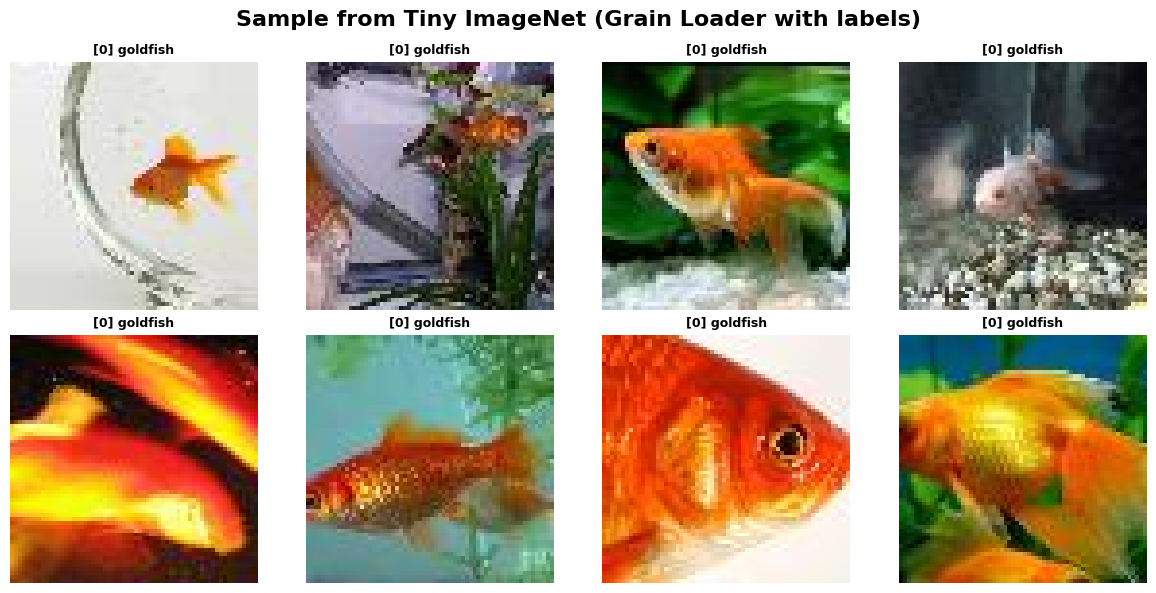

In [19]:
# We will find out the actual number of images in the batch (in debug 8, actually more)
num_images = min(len(images), 16)

# We dynamically create a grid based on the number of images available
# If we have 8 images, we make 2 rows and 4 columns. Otherwise 4x4.
rows = 2 if num_images <= 8 else 4
cols = 4

fig, axes = plt.subplots(rows, cols, figsize=(12, 3 * rows))
fig.suptitle("Sample from Tiny ImageNet (Grain Loader with labels)", fontsize=16, weight="bold")

for i, ax in enumerate(axes.flat):
    if i < num_images:
        # Convert from range [-1, 1] back to [0, 1] for matplotlib
        img_to_show = (images[i] + 1.0) / 2.0
        img_to_show = np.clip(img_to_show, 0.0, 1.0)

        # Get the class name
        class_idx = int(labels[i])
        class_name = TINY_IMAGENET_CLASSES[class_idx].replace("_", " ")

        # Render the image
        ax.imshow(img_to_show)
        ax.set_title(f"[{class_idx}] {class_name}", fontsize=9, weight="semibold")
        ax.axis("off")
    else:
        # Hide empty cells if there are fewer than the grid size
        ax.axis("off")

plt.tight_layout()
plt.show()

----------------------------------------------------
## ***3. CORRUPTION PROCESS (Adding noise in JAX)***
----------------------------------------------------

In [20]:
def corrupt_jax(rng, x, amount):
    """
    Linearly interpolates between the clean image (x) and standard normal noise.
    Suitable for data range [-1, 1].
    """
    noise = jax.random.normal(rng, shape=x.shape)
    # Reshape amounts from (B,) or (B, 1) to (B, 1, 1, 1) for proper broadcast
    amount = amount.reshape(-1, 1, 1, 1)
    return x * (1.0 - amount) + noise * amount

-----------------------------------------------------------------------
## ***4. PRODUCTION ARCHITECTURE: ConditionalMediumUNet WITH DUAL CONDITIONING***
-----------------------------------------------------------------------

Now we will build the core engine of our generative pipeline: the `ConditionalMediumUNet`. Unlike the primitive architectures used for simple datasets, this production-ready network must handle 3-channel RGB color spaces, scale gracefully to a $64 \times 64$ spatial resolution, and balance two distinct conditioning signals simultaneously.

### The Conditioning Injection Strategy
*   **Time/Noise Embedding:** Maps the continuous scalar `amount` ($t$) into a high-dimensional continuous feature space using sinusoidal functions.
*   **Class Embedding:** Maps the discrete category token ($c \in [0, 199]$) into a dense, learnable vector representation using a lookup dictionary layer.
*   **Fusion Layer:** Combines both vectors into a unified conditioning context that is broadcast directly into the residual channels at every encoder and decoder stage, steering the U-Net toward the target distribution.

In [55]:
def sinusoidal_embedding(amounts, embedding_dim=32):
    """Transforms scalar noise levels (amounts) into positional sinusoidal embeddings."""
    # Instead of .squeeze() we force an exact 1D shape [Batch] even for traced scalars
    amounts = jnp.atleast_1d(amounts).reshape(-1)

    half_dim = embedding_dim // 2
    emb = jnp.log(10000.0) / (half_dim - 1)
    emb = jnp.exp(jnp.arange(half_dim, dtype=jnp.float32) * -emb)

    # Matrix calculation [Batch, half_dim]
    emb = amounts[:, None] * emb[None, :]
    emb = jnp.concatenate([jnp.sin(emb), jnp.cos(emb)], axis=-1)
    return emb

--------------------------------------------------------------------
## ***5. MODEL: ConditionalRealNanoUNet***
--------------------------------------------------------------------

In [56]:
class ConditionalMediumUNet(nnx.Module):
    """
    A strengthened version of UNet for Tiny ImageNet (64x64x3).
    It has a larger capacity (channels 32 -> 64 -> 128) and deeper downsampling (up to 16x16),
    which is key to remembering and drawing the more complex details of the 200 classes.
    """
    def __init__(self, in_features: int, out_features: int, num_classes: int = 200, rngs: nnx.Rngs = None):
        super().__init__()
        emb_dim = 64
        class_emb_dim = 64

        # 1. Stronger embeddings
        self.class_emb = nnx.Embed(num_classes, class_emb_dim, rngs=rngs)
        self.cond_proj1 = nnx.Linear(emb_dim + class_emb_dim, 128, rngs=rngs)
        self.cond_proj2 = nnx.Linear(128, emb_dim, rngs=rngs)

        # Time projections for multiple floors
        self.time_mlp1 = nnx.Linear(emb_dim, 32, rngs=rngs)
        self.time_mlp2 = nnx.Linear(emb_dim, 64, rngs=rngs)
        self.time_mlp3 = nnx.Linear(emb_dim, 128, rngs=rngs) # Bottleneck
        self.time_mlp4 = nnx.Linear(emb_dim, 64, rngs=rngs)
        self.time_mlp5 = nnx.Linear(emb_dim, 32, rngs=rngs)

        # --- DOWNSAMPLING ---
        # Floor 1: 64x64 -> 32
        self.down1_conv1 = nnx.Conv(in_features, 32, kernel_size=(3, 3), padding="SAME", rngs=rngs)
        self.down1_conv2 = nnx.Conv(32, 32, kernel_size=(3, 3), padding="SAME", rngs=rngs)

        # Floor 2: 64x64 -> 32x32 -> 64 channels
        self.down2_stride = nnx.Conv(32, 64, kernel_size=(3, 3), strides=(2, 2), padding="SAME", rngs=rngs)
        self.down2_conv1  = nnx.Conv(64, 64, kernel_size=(3, 3), padding="SAME", rngs=rngs)

        # Layer 3 (Bottleneck): 32x32 -> 16x16 -> 128 channels (Key for deeper semantics!)
        self.down3_stride = nnx.Conv(64, 128, kernel_size=(3, 3), strides=(2, 2), padding="SAME", rngs=rngs)
        self.down3_conv1  = nnx.Conv(128, 128, kernel_size=(3, 3), padding="SAME", rngs=rngs)

        # --- UPSAMPLING ---
        # Patro 4: 16x16 -> 32x32
        self.up1_transpose = nnx.ConvTranspose(128, 64, kernel_size=(3, 3), strides=(2, 2), padding="SAME", rngs=rngs)
        self.up1_conv1     = nnx.Conv(64, 64, kernel_size=(3, 3), padding="SAME", rngs=rngs)

        # Patro 5: 32x32 -> 64x64
        self.up2_transpose = nnx.ConvTranspose(64, 32, kernel_size=(3, 3), strides=(2, 2), padding="SAME", rngs=rngs)
        self.up2_conv1     = nnx.Conv(32, 32, kernel_size=(3, 3), padding="SAME", rngs=rngs)

        # Output layers
        self.out_conv1 = nnx.Conv(32, 32, kernel_size=(3, 3), padding="SAME", rngs=rngs)
        self.out_conv2 = nnx.Conv(32, out_features, kernel_size=(3, 3), padding="SAME", rngs=rngs)

    def __call__(self, x, amounts, class_labels):
        t_emb = sinusoidal_embedding(amounts, embedding_dim=64)
        cl_emb = self.class_emb(class_labels)

        joint_cond = jnp.concatenate([t_emb, cl_emb], axis=-1)
        joint_cond = jax.nn.silu(self.cond_proj1(joint_cond))
        joint_cond = jax.nn.silu(self.cond_proj2(joint_cond))

        t_proj1 = self.time_mlp1(joint_cond)[:, None, None, :]
        t_proj2 = self.time_mlp2(joint_cond)[:, None, None, :]
        t_proj3 = self.time_mlp3(joint_cond)[:, None, None, :]
        t_proj4 = self.time_mlp4(joint_cond)[:, None, None, :]
        t_proj5 = self.time_mlp5(joint_cond)[:, None, None, :]

        # Down 1 (64x64x32)
        h1 = jax.nn.silu(self.down1_conv1(x) + t_proj1)
        h1 = jax.nn.silu(self.down1_conv2(h1))

        # Down 2 (32x32x64)
        h2 = jax.nn.silu(self.down2_stride(h1))
        h2 = jax.nn.silu(self.down2_conv1(h2) + t_proj2)

        # Down 3 / Bottleneck (16x16x128)
        h3 = jax.nn.silu(self.down3_stride(h2))
        h3 = jax.nn.silu(self.down3_conv1(h3) + t_proj3)

        # Up 1 (from 16x16x128 back to 32x32x64)
        h4 = jax.nn.silu(self.up1_transpose(h3))
        h4 = h4 + h2  # Skip connection from h2
        h4 = jax.nn.silu(self.up1_conv1(h4) + t_proj4)

        # Up 2 (from 32x32x64 back to 64x64x32)
        h5 = jax.nn.silu(self.up2_transpose(h4))
        h5 = h5 + h1  # Skip connection from h1
        h5 = jax.nn.silu(self.up2_conv1(h5) + t_proj5)

        # Final projection on 3 RGB channels
        h6 = jax.nn.silu(self.out_conv1(h5))
        return self.out_conv2(h6)

#### ***Initializing the random number generator for Flax NNX***

In [57]:
model_rngs = nnx.Rngs(42)

#### ***Creating a new augmented model for 3 channels and 200 classes***

In [58]:
model = ConditionalMediumUNet(in_features=3, out_features=3, num_classes=200, rngs=model_rngs)

#### ***We will extract images and labels from the test batch from the loader***

In [59]:
batch_img = batch["pixel_values"]
batch_labels = batch["label"]

#### ***Preparation of sample noise levels (e.g. 0.5 for the entire batch)***

In [60]:
sample_amounts = jnp.array([0.5] * batch_img.shape[0], dtype=jnp.float32)

#### ***Running a forward pass (adding batch_labels as the third parameter)***

batch_img now has the shape [B, 64, 64, 3] and batch_labels has the shape [B]

In [61]:
y_test_pred = model(batch_img, sample_amounts, batch_labels)

In [62]:
print("The shape of MediumUNet's real conditional prediction:", y_test_pred.shape)

The shape of MediumUNet's real conditional prediction: (8, 64, 64, 3)


You should see the output: (B, 64, 64, 3)

----------------------------------------------------------
## ***5. ASYNCHRONOUS FILE LOG (KAGGLE SAFE)***
----------------------------------------------------------

#### Setting up the logging mechanism

In [63]:
log_filename = "/content/training_diffusion.log"

#### Reset any old loggers so that the file is not overwritten wildly when the cell is restarted

In [64]:
for handler in logging.root.handlers[:]:
    logging.root.removeHandler(handler)

In [65]:
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    handlers=[
        logging.FileHandler(log_filename, mode="w", encoding="utf-8"),
        # We will also keep the stream to the console, but suppress the logger so as not to overload Kaggle
    ]
)

----------------------------------------------------------
## ***6. CONFIGURATION & SCHEDULER***
----------------------------------------------------------

#### Parameters for the learning scheduler
#### Dynamic settings depending on whether we are tuning or training live

In [66]:
NUM_EPOCHS = 1 if DEBUG else 100
LOG_EVERY_N_BATCHES = 1 if DEBUG else 50

# 📉 STEP CALCULATION FOR TINY IMAGENET (100,000 images)
warmup_steps = 500
total_steps = NUM_EPOCHS * (TOTAL_TRAIN_SAMPLES // BATCH_SIZE)

In [67]:
print(f"⚙️ Configuration: DEBUG={DEBUG} | Epochs={NUM_EPOCHS} | Logging every {LOG_EVERY_N_BATCHES} batches")
print(f"⚙️ Total training steps calculated for schedule: {total_steps}")

⚙️ Configuration: DEBUG=True | Epochs=1 | Logging every 1 batches
⚙️ Total training steps calculated for schedule: 12500


In [68]:
lr_schedule = optax.warmup_cosine_decay_schedule(
    init_value=0.0,
    peak_value=1e-4,
    warmup_steps=warmup_steps,
    decay_steps=total_steps,
    end_value=1e-6
)

#### Robust NNX Optimizer with explicit wrt=nnx.Param

In [69]:
optimizer = nnx.Optimizer(
    model,
    optax.chain(
        optax.clip_by_global_norm(1.0),
        optax.adamw(lr_schedule, weight_decay=0.1)
    ),
    wrt=nnx.Param
)

----------------------------------------------------------
## ***7. TRAIN STEP***
----------------------------------------------------------

In [70]:
@nnx.jit
def train_step(model, optimizer, batch, step_rng):
    """Training step fully compatible with Flax >= 0.11.0 API and Tiny ImageNet."""
    rng1, rng2 = jax.random.split(step_rng)

    # 1. Unpacking real data from the loader dictionary
    real_images = batch["pixel_values"]  # Shape: [B, 64, 64, 3]
    class_labels = batch["label"]        # Shape: [B]

    # 2. Generating a continuous noise level
    noise_amount = jax.random.uniform(rng1, shape=(real_images.shape[0],))

    # 3. Image noise
    noisy_inputs = corrupt_jax(rng2, real_images, noise_amount)

    # 4. Definition of loss function
    def loss_fn(model):
        # The model now requires 3 arguments: input, time, and class
        pred = model(noisy_inputs, noise_amount, class_labels)
        # We calculate the MSE loss compared to the original clean image (real_images)
        return jnp.mean((pred - real_images) ** 2)

    loss, grads = nnx.value_and_grad(loss_fn)(model)

    # 5. Updating model weights
    optimizer.update(model, grads)

    return loss

In [71]:
# 1. Preparing history for storing values ​​to plot on a graph
history = {
    "train_loss": [],
    "val_loss": []
}

In [72]:
print(f"\n🚀 I start training. All details are written to the file: {log_filename}")
logging.info("--- START TRAINING NANOUNET ---")

# Loader for Tiny ImageNet
train_loader_prod = get_grain_tiny_imagenet_dataset(batch_size=BATCH_SIZE, debug_mode=DEBUG, train=True)
test_loader_prod = get_grain_tiny_imagenet_dataset(batch_size=BATCH_SIZE, debug_mode=DEBUG, train=False)

loop_rng = jax.random.PRNGKey(101)


🚀 I start training. All details are written to the file: /content/training_diffusion.log
📥 Loading Tiny ImageNet training set from Hugging Face... 
🔬 DEBUG TRAIN ACTIVE: Taking exactly 1200 training samples.
📥 Loading Tiny ImageNet validation set from Hugging Face...
🔬 DEBUG VALID ACTIVE: Taking exactly 200 validation samples.


In [73]:
# Initialize tqdm bar
epoch_bar = tqdm(range(NUM_EPOCHS), desc="Overall training", unit=" epoch")

for epoch in range(NUM_EPOCHS):
    # --- TRAINING PHASE ---
    epoch_train_losses = []
    batch_idx = 0

    for batch_x in train_loader_prod:
        # Fixed stop in case of DEBUG mode (DEBUG_MAX_BATCHES)
        if DEBUG_MAX_BATCHES is not None and batch_idx >= DEBUG_MAX_BATCHES:
            break

        loop_rng, step_rng = jax.random.split(loop_rng)
        loss_val = train_step(model, optimizer, batch_x, step_rng)

        current_loss = float(loss_val)
        epoch_train_losses.append(current_loss)

        if batch_idx % LOG_EVERY_N_BATCHES == 0:
            logging.info(f"Epoch {epoch+1}/{NUM_EPOCHS} | Batch {batch_idx} | Train Loss: {current_loss:.6f}")

        batch_idx += 1

    avg_train_loss = np.mean(epoch_train_losses)
    history["train_loss"].append(avg_train_loss)

    # --- VALIDATION PHASE ---
    epoch_val_losses = []
    val_batch_idx = 0

    for batch_val_x in test_loader_prod:
        # Limit validation in debug or full run (max 100 batches), so we don't have to wait forever
        if DEBUG_MAX_BATCHES is not None and val_batch_idx >= max(1, DEBUG_MAX_BATCHES // 5):
            break
        if not DEBUG and val_batch_idx >= 100:
            break

        loop_rng, step_rng = jax.random.split(loop_rng)

        # Unpacking the Tiny ImageNet dictionary for validation
        real_val_images = batch_val_x["pixel_values"]
        val_class_labels = batch_val_x["label"]

        rng1, rng2 = jax.random.split(step_rng)
        noise_amount = jax.random.uniform(rng1, shape=(real_val_images.shape[0],))
        noisy_inputs = corrupt_jax(rng2, real_val_images, noise_amount)

        # Network prediction (now with 3 arguments: input, time, class)
        pred = model(noisy_inputs, noise_amount, val_class_labels)
        val_loss_val = jnp.mean((pred - real_val_images) ** 2)

        epoch_val_losses.append(float(val_loss_val))
        val_batch_idx += 1

    avg_val_loss = np.mean(epoch_val_losses)
    history["val_loss"].append(avg_val_loss)

    # Logging at the end of the epoch
    logging.info(f"✨ END OF AN EPOCH {epoch+1} | Average Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
    print(f"✨ Epoch {epoch+1}/{NUM_EPOCHS} done | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

    # Update tqdm
    epoch_bar.update(1)

epoch_bar.close()
logging.info("--- TRAINING SUCCESSFULLY COMPLETED ---")

Overall training: 100%|██████████| 1/1 [00:10<00:00, 10.47s/ epoch]

✨ Epoch 1/1 done | Train Loss: 0.3346 | Val Loss: 0.2791


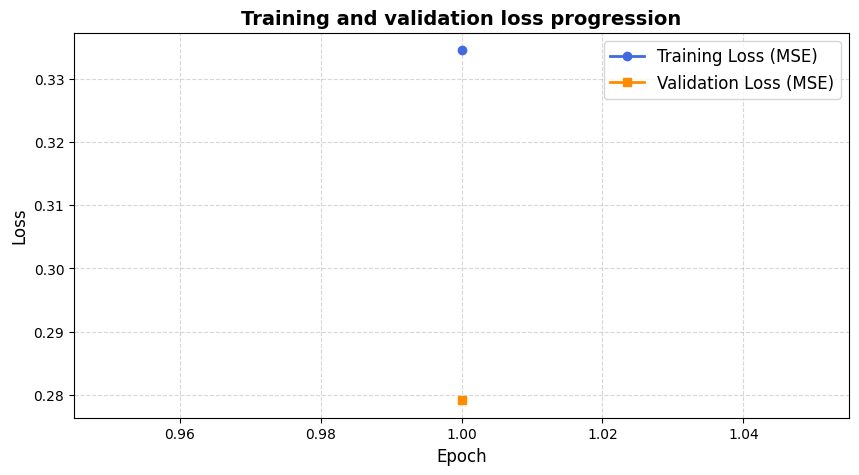

In [74]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, NUM_EPOCHS + 1), history["train_loss"], label="Training Loss (MSE)", color="royalblue", lw=2, marker='o')
plt.plot(range(1, NUM_EPOCHS + 1), history["val_loss"], label="Validation Loss (MSE)", color="darkorange", lw=2, marker='s')

plt.title("Training and validation loss progression", fontsize=14, fontweight='bold')
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(fontsize=12)

# If the values ​​have dropped significantly, we will use a logarithmic scale
if history["train_loss"][0] / (history["train_loss"][-1] + 1e-8) > 5:
    plt.yscale("log")
    plt.title("Loss Progress (Logarithmic Scale)", fontsize=14, fontweight='bold')

plt.show()

#### Saving a real checkpoint

In [75]:
graphdef, model_state = nnx.split(model)
checkpoint_dir = os.path.abspath("./conditional_medium_unet_checkpoint")
checkpointer = ocp.Checkpointer(ocp.StandardCheckpointHandler())
checkpointer.save(checkpoint_dir, model_state, force=True)
print(f"💾 Orbax checkpoint of new conditional model saved to: {checkpoint_dir}")

💾 Orbax checkpoint of new conditional model saved to: /content/conditional_medium_unet_checkpoint


------------------------------------------------------------------------
## ***7. SAMPLING (Generating new data from noise in 10 steps)***
------------------------------------------------------------------------

In [76]:
def sample_from_noise_conditional_hq(model, rng, class_label, n_steps=60):
    """
    Improved HQ sampler with quadratic timing for sharper Tiny ImageNet details.
    Recommended: 50-100 steps.
    """
    rng_start, _ = jax.random.split(rng)
    x = jax.random.normal(rng_start, shape=(4, 64, 64, 3))
    labels = jnp.full((4,), class_label, dtype=jnp.int32)
    model.eval()

    # Quadratic schedule: gives more steps to fine denoising at the end (near t=0)
    # jnp.linspace(1, 0) squared
    steps_line = jnp.linspace(1.0, 0.0, n_steps + 1)
    ts = steps_line ** 2

    for i in range(n_steps):
        t_curr = ts[i]
        t_next = ts[i + 1]

        current_amount = jnp.ones((4,)) * t_curr

        pred_clean = model(x, current_amount, labels)

        # Dynamic Thresholding – the key to saturated and sharp colors
        pred_clean = jnp.clip(pred_clean, -1.0, 1.0)

        if i == n_steps - 1:
            x = pred_clean
            break

        # Mathematical correction (DDIM) with adjusted t_curr and t_next
        eps_estimated = (x - (1.0 - t_curr) * pred_clean) / (t_curr + 1e-8)
        x = (1.0 - t_next) * pred_clean + t_next * eps_estimated

    # Convert to [0, 1] for matplotlib
    final_images = (x + 1.0) / 2.0
    return np.array(jnp.clip(final_images, 0.0, 1.0))

RNG key distribution for sampling

In [77]:
loop_rng, sample_rng = jax.random.split(loop_rng)

Generating 4 color images for a specific class (e.g. 42) with 80 steps<br>
Definition of the selected class

In [78]:
CHOSEN_CLASS = 42  # Class index from Tiny ImageNet (0 to 199)

Extracting a class text name from a list

In [79]:
class_name = TINY_IMAGENET_CLASSES[CHOSEN_CLASS]

In [80]:
generated_images = sample_from_noise_conditional_hq(
    model=model,
    rng=sample_rng,
    class_label=CHOSEN_CLASS,
    n_steps=80
)

Plotting the results

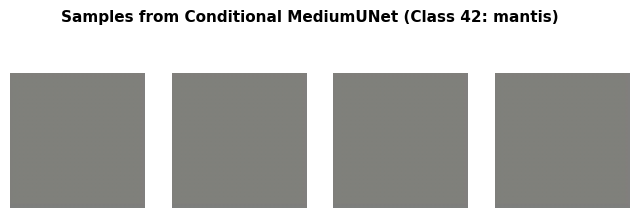

In [81]:
fig, axs = plt.subplots(1, 4, figsize=(8, 2))
fig.suptitle(f"Samples from Conditional MediumUNet (Class {CHOSEN_CLASS}: {class_name})", y=1.15, fontsize=11, fontweight='bold')

for i in range(4):
    # We draw the entire RGB image [i], we do not use a gray map or channel clipping
    axs[i].imshow(generated_images[i])
    axs[i].axis('off')

plt.show()

------------------------------------------------------------------------------
## ***8. DEEP EXPORT WITH MULTIPLE INPUTS: MLIR, STABLEHLO***
------------------------------------------------------------------------------

In [82]:
print("\n--- Starting Multi-Format Export Pipeline ---")
export_dir = "/content/hf_real_export_package"
os.makedirs(export_dir, exist_ok=True)


--- Starting Multi-Format Export Pipeline ---


#### Preparing sample inputs with new dimensions for Tiny ImageNet

In [83]:
sample_x = jnp.zeros((1, 64, 64, 3), dtype=jnp.float32)
sample_t = jnp.array([0.5], dtype=jnp.float32)
sample_label = jnp.array([42], dtype=jnp.int32) # Sample label as int32 array

#### 🔥 Switching the model to eval mode and splitting the state

In [84]:
model.eval()

In [85]:
graphdef, state = nnx.split(model)

Modifying an exportable function with a third argument (label)

In [86]:
@jax.jit
def exportable_forward(x, t, label):
    # Make sure that both time and label have the correct dimensions for embeddings
    t_fixed = jnp.asarray(t, dtype=jnp.float32).reshape((1,))
    label_fixed = jnp.asarray(label, dtype=jnp.int32).reshape((1,))

    # We now call the model with 3 parameters
    return model(x, t_fixed, label_fixed)

In [87]:
print("📦 Running cross-platform jax.export.export...")

📦 Running cross-platform jax.export.export...


#### 🔥 MULTIPLATFORM EXPORT ACCORDING TO THE LATEST JAX DOCUMENTATION

Running the export – we also need to pass the sample label into the tuple arguments

In [88]:
exported = jax.export.export(
    exportable_forward,
    platforms=['cpu', 'cuda', 'tpu']
)(sample_x, sample_t, sample_label)

#### Writing MLIR and StableHLO files under new names

In [89]:
mlir_path = os.path.join(export_dir, "conditional_medium_unet.mlir")

In [90]:
with open(mlir_path, "w", encoding="utf-8") as f:
    f.write(exported.mlir_module())

print(f"📄 Native MLIR module stored in: {mlir_path}")

📄 Native MLIR module stored in: /content/hf_real_export_package/conditional_medium_unet.mlir


#### Uložení binárního zkompilovaného `.stablehlo` artefaktu
According to the official API, the `.serialize()` method is used to write to disk

In [91]:
stablehlo_path = os.path.join(export_dir, "conditional_medium_unet.stablehlo")

In [92]:
with open(stablehlo_path, "wb") as f:
    f.write(exported.serialize())

print(f"💾 Cross-platform StableHLO artifact saved to: {stablehlo_path}")
print("\n🎉 EXPORT COMPLETED SUCCESSFULLY!")

💾 Cross-platform StableHLO artifact saved to: /content/hf_real_export_package/conditional_medium_unet.stablehlo

🎉 EXPORT COMPLETED SUCCESSFULLY!


----------------------------------------------------
## ***9. INDEPENDENT STABLEHLO RUNTIME VERIFICATION***
----------------------------------------------------

#### 1. We load binary data from disk

In [93]:
print("🔬 Loading and validating StableHLO model...")

# 1. Loading a new conditional StableHLO binary
with open(f"{export_dir}/conditional_medium_unet.stablehlo", "rb") as f:
    serialized_bytes = f.read()

🔬 Loading and validating StableHLO model...


#### 2. Deserialize back to a callable JAX object

In [94]:
loaded_artifact = jax.export.deserialize(serialized_bytes)

#### 3. Compile into a JIT graph for fast hardware run

We call the loaded artifact using the .call method

In [95]:
compiled_fn = jax.jit(loaded_artifact.call)

#### 4. Initializing pure normal noise (batch_size=1, 64x64, 3 channels)

In [96]:
key = jax.random.PRNGKey(42)
x = jax.random.normal(key, shape=(1, 64, 64, 3))

Setting up a test class for StableHLO inference

In [97]:
CHOSEN_CLASS = 42
sample_label = jnp.array([CHOSEN_CLASS], dtype=jnp.int32)
class_name = TINY_IMAGENET_CLASSES[CHOSEN_CLASS]

Quadratic schedule for 80 steps (identical to production sampler)

In [98]:
n_steps = 80
steps_line = jnp.linspace(1.0, 0.0, n_steps + 1)
ts = steps_line**2

#### Iterative denoising directly via the compiled StableHLO function

In [99]:
print("⚡ StableHLO model hardware inference is running...")

for i in range(n_steps):
    t_curr = ts[i]
    t_next = ts[i + 1]
    current_amount = jnp.array([t_curr], dtype=jnp.float32)

    # 🔥 CALL STABLEHLO: We pass 3 parameters (x, time, label)
    pred_clean = compiled_fn(x, current_amount, sample_label)
    pred_clean = jnp.clip(pred_clean, -1.0, 1.0)

    if i == n_steps - 1:
        x = pred_clean
        break

    # Mathematical correction (DDIM) ported to StableHLO
    eps_estimated = (x - (1.0 - t_curr) * pred_clean) / (t_curr + 1e-8)
    x = (1.0 - t_next) * pred_clean + t_next * eps_estimated

print("✅ Independent StableHLO generation completed!")
print(f"✅ Verification completed! Output shape: {x.shape}")

⚡ StableHLO model hardware inference is running...
✅ Independent StableHLO generation completed!
✅ Verification completed! Output shape: (1, 64, 64, 3)


Converting the range back from [-1, 1] to [0, 1] for correct colors

In [100]:
final_image_rescaled = (x + 1.0) / 2.0
final_image_rescaled = jnp.clip(final_image_rescaled, 0.0, 1.0)

#### 🖼️ Plotting the result of the compiled StableHLO model

🎨 Rendering output from StableHLO...


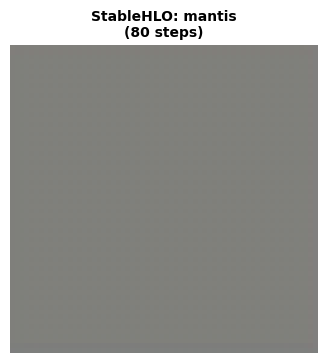

In [101]:
print("🎨 Rendering output from StableHLO...")

# We only remove the batch dimension: (1, 64, 64, 3) -> (64, 64, 3)
output_image = np.array(final_image_rescaled)[0]

plt.figure(figsize=(4, 4))
plt.imshow(output_image) # We render a color RGB image
plt.title(f"StableHLO: {class_name}\n({n_steps} steps)", fontsize=10, fontweight='bold')
plt.axis("off")
plt.show()

#### 5. Packing Orbax checkpoint into an export package

In [102]:
shutil.copytree(checkpoint_dir, f"{export_dir}/jax_checkpoint", dirs_exist_ok=True)

'/content/hf_real_export_package/jax_checkpoint'

In [103]:
print(f"📦 All conditional MediumUNet formats are ready to be sent in the {export_dir} folder")

📦 All conditional MediumUNet formats are ready to be sent in the /content/hf_real_export_package folder


------------------------------------------------------------------------------
## ***10. PUBLISHING TO THE HUGGING FACE HUB (with an auto-generated Model Card)***
------------------------------------------------------------------------------

In [104]:
# 🔧 Changing the repository name for the conditional Tiny ImageNet model
HF_REPO_ID = "KRadim/conditional-medium-unet-tiny-imagenet"
PUSH_TO_HUB = not DEBUG  # Prevents unwanted recording while debugging

#### Authenticating with the Hugging Face Hub

In [105]:
if PUSH_TO_HUB:
    if hf_token:
        hf_login(token=hf_token)
    else:
        hf_login()  # interactive token prompt
else:
    print("ℹ️ PUSH_TO_HUB is False - skipping Hub authentication.")

ℹ️ PUSH_TO_HUB is False - skipping Hub authentication.


#### Generating the Model Card (README.md) with metadata

In [106]:
card_data = ModelCardData(
    language="en",
    license="mit",
    library_name="jax",
    tags=["diffusion-model", "flax", "flax-nnx", "jax", "unet", "tiny-imagenet", "conditional-image-generation", "from-scratch"],
    datasets=["tiny_imagenet"],
    pipeline_tag="conditional-image-generation",
)

training_data_desc = "1200 debug samples" if DEBUG else "full 100,000-image Tiny ImageNet training set"

model_card_text = f"""
# Conditional MediumUNet Diffusion Model (Flax NNX, JAX)

A class-conditional, from-scratch DDPM-style diffusion model trained on **Tiny ImageNet ($64 \times 64 \times 3$, 200 classes)**, built using **JAX** and **Flax NNX**.
The model architecture (`ConditionalMediumUNet`) predicts the clean image from a noisy input, conditioned simultaneously on a sinusoidally embedded continuous noise level and a class label embedding.

## Model Details

- **Architecture:** Medium U-Net with Class Conditioning (featuring sinusoidal time embeddings, learnable class embeddings, strided convolutions for downsampling, transposed convolutions for upsampling, and functional residual skip connections)
- **Conditioning:**
  1. Scalar noise level `amount ∈ [0, 1]` via sinusoidal positional embeddings.
  2. Class index `label ∈ [0, 199]` via dense embedding vectors injected into the residual blocks.
- **Framework:** JAX / Flax NNX
- **Training data:** Tiny ImageNet (200 classes) — {training_data_desc}
- **Optimizer:** AdamW with warmup-cosine-decay LR schedule, gradient clipping (global norm 1.0)
- **Epochs:** {NUM_EPOCHS}
- **Batch size:** {BATCH_SIZE}

## Exported Formats

This repository bundles multiple export formats of the same trained weights:

| File / Folder | Format | Notes |
|---|---|---|
| `model_checkpoint/` | Orbax checkpoint | Native JAX/Flax NNX state, load with `orbax.checkpoint` |
| `conditional_medium_unet.mlir` | MLIR | StableHLO dialect, via `jax.export` |
| `conditional_medium_unet.stablehlo` | StableHLO bytecode | Portable compiled representation (**with 100% baked-in weights**) |

## Usage (JAX / Flax NNX Native)

```python
import orbax.checkpoint as ocp
from flax import nnx

# Recreate the model skeleton, then restore the trained parameters
model = ConditionalMediumUNet(in_features=3, out_features=3, num_classes=200, rngs=nnx.Rngs(0))
graphdef, abstract_state = nnx.split(model)

checkpointer = ocp.Checkpointer(ocp.StandardCheckpointHandler())
state = checkpointer.restore("model_checkpoint", abstract_state)
model = nnx.merge(graphdef, state)
```

## ⚡ How to use the StableHLO Model (Production Inference)

The ultimate advantage of this pipeline is that you **don't need the Python architecture class anymore, nor do you need to manage raw weight parameters!** Because the model was exported via a functional static JIT trace, all trained weights are **fully baked directly into the StableHLO bytecode binary**. The compiled graph acts as a completely autonomous black-box function.

Here is how to properly load and execute the pre-compiled StableHLO graph to perform a full iterative diffusion reverse loop using pure JAX with the **HQ quadratic schedule (80 steps)**:

```python
import jax
import jax.numpy as jnp
import numpy as np

# 1. Load the pre-compiled StableHLO bytecode from file
with open("conditional_medium_unet.stablehlo", "rb") as f:
    stablehlo_bytecode = f.read()

# 2. Deserialize it back into a callable JAX artifact and JIT compile it
loaded_artifact = jax.export.deserialize(stablehlo_bytecode)
compiled_fn = jax.jit(loaded_artifact.call)

# 3. Initialize pure normal noise (batch_size=1, 64x64, 3 channels)
key = jax.random.PRNGKey(42)
x = jax.random.normal(key, shape=(1, 64, 64, 3))

# Choose class label (e.g., 42 for 'mantis')
CHOSEN_CLASS = 42
sample_label = jnp.array([CHOSEN_CLASS], dtype=jnp.int32)

# 4. Set up the HQ Quadratic Schedule (80 steps)
n_steps = 80
steps_line = jnp.linspace(1.0, 0.0, n_steps + 1)
ts = steps_line ** 2

print("🚀 Running conditional inference loop via independent StableHLO runtime...")
for i in range(n_steps):
    t_curr = ts[i]
    t_next = ts[i + 1]
    current_amount = jnp.array([t_curr], dtype=jnp.float32)

    # 🔥 LIGHTNING-FAST HARDWARE INFERENCE:
    # Pass image, time step, and class label. No model state or weights needed!
    pred_clean = compiled_fn(x, current_amount, sample_label)
    pred_clean = jnp.clip(pred_clean, -1.0, 1.0)

    if i == n_steps - 1:
        x = pred_clean
        break

    # DDIM Mathematical Correction
    eps_estimated = (x - (1.0 - t_curr) * pred_clean) / (t_curr + 1e-8)
    x = (1.0 - t_next) * pred_clean + t_next * eps_estimated

# Rescale from [-1, 1] back to [0, 1] for image display
final_image = np.array((x + 1.0) / 2.0)[0]
print("✅ Image generated successfully! Output shape:", final_image.shape)
```

## Technical Parameters & Design Choices

- **Color & Resolution:** Native support for $64 \times 64$ RGB images, a massive step up in spatial complexity compared to standard MNIST benchmarks.
- **Class-Conditional Latent Guidance:** Embedding-driven injection allows targeted generation of specific objects among 200 distinct classes, turning the network from an unconditional sampler into a controllable asset.
- **Production Readiness:** Ideal for specialized target applications on low-power edge nodes or cross-language backends (C++, Rust) via the native StableHLO runtime interface.

"""

card = ModelCard(model_card_text, ignore_metadata_errors=True)
card.data = card_data
card.save(f"{export_dir}/README.md")
print(f"📝 Model card written to {export_dir}/README.md")

Repo card metadata block was not found. Setting CardData to empty.


📝 Model card written to /content/hf_real_export_package/README.md


#### Creating the repo and pushing everything (checkpoint + MLIR/StableHLO + model card) to the Hub

In [107]:
if PUSH_TO_HUB:
    # 1. Paths to your folders on Kagglu (as shown in the image)
    checkpoint_src = "/content/conditional_medium_unet_checkpoint"
    checkpoint_dst = os.path.join(export_dir, "model_checkpoint")

    # 2. 🔥 Copying the checkpoint to the export folder if it is not already there
    if os.path.exists(checkpoint_src) and not os.path.exists(checkpoint_dst):
        print("📦 Copying Orbax checkpoint to export package...")
        shutil.copytree(checkpoint_src, checkpoint_dst)

    print(f"🤗 Connecting to Hugging Face Hub and creating repository {HF_REPO_ID}...")
    api = HfApi()
    api.create_repo(repo_id=HF_REPO_ID, repo_type="model", exist_ok=True)

    commit_msg = "Upload Conditional MediumUNet model (Orbax checkpoint + native MLIR + compiled StableHLO artifact)"

    print(f"🚀 Sending COMPLETE package (models + checkpoint) from '{export_dir}'...")

    api.upload_folder(
        repo_id=HF_REPO_ID,
        folder_path=export_dir,
        repo_type="model",
        commit_message=commit_msg,
    )
    print(f"🎉 Done! Everything (scales and compiled models) is live at: https://huggingface.co/{HF_REPO_ID}")
else:
    print("ℹ️ PUSH_TO_HUB is False (DEBUG run) - skipping upload.")

ℹ️ PUSH_TO_HUB is False (DEBUG run) - skipping upload.
